<a href="https://colab.research.google.com/github/jetsada24184/DSP-Labs/blob/main/Y3Lab1_worksheet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Year 3 · Lab 1: Heart Rate from Your Phone
### *วัดชีพจรด้วยกล้องมือถือ*
**DSP Lab Series · team of 3 · 100 points · about 3 hours / ทีมละ 3 คน ประมาณ 3 ชั่วโมง**

Today your team turns a 20-second fingertip video into a heart-rate monitor — the same idea (PPG) used by smartwatches — and proves how accurate it is.
*วันนี้ทีมของคุณจะเปลี่ยนวิดีโอปลายนิ้ว 20 วินาทีให้เป็นเครื่องวัดชีพจร และพิสูจน์ว่าแม่นแค่ไหน*

| Part | Topic | หัวข้อ | Points | Suggested time |
|---|---|---|---|---|
| 1 | From video to signal | จากวิดีโอเป็นสัญญาณ | 20 | 35 min |
| 2 | Clean it | ทำความสะอาดสัญญาณ | 25 | 40 min |
| 3 | Count the beats | นับชีพจร | 25 | 40 min |
| 4 | Validate | พิสูจน์ความแม่นยำ | 20 | 35 min |
| 5 | Stress test | ทดสอบความทนทาน | 10 | 30 min |

> ⚠️ **Ethics / จริยธรรม:** This is **not a medical device** — never use it to diagnose anyone. Film **only a fingertip**. You may use the **sample videos** instead of your own data for the same marks. **Do not submit video files**; delete them after grading.
> *ไม่ใช่เครื่องมือแพทย์ ถ่ายเฉพาะปลายนิ้ว ใช้วิดีโอตัวอย่างแทนได้โดยไม่หักคะแนน ห้ามส่งไฟล์วิดีโอ*

### How to record / วิธีอัดวิดีโอ
Turn on the **flash (torch)**, cover **both the camera and the flash** with your fingertip, press **lightly**, keep still, record **20 s**. *เปิดไฟฉาย ใช้ปลายนิ้วปิดทั้งกล้องและแฟลช กดเบา ๆ อยู่นิ่ง ๆ อัด 20 วินาที*

### Rules / กติกา
Fill in every `# TODO`, answer every ✍️ cell, plots need axis labels with units (write plot text in English). Before submitting: **Runtime › Restart and run all** → **File › Download .ipynb** → name it `Y3Lab1_<teamID>.ipynb` → upload to [LMS] before [day, time].

## Part 0 · Setup — run this first
*ส่วนที่ 0 · ตั้งค่า — รัน cell นี้ก่อนเสมอ*

In [2]:
TEAM_ID = "T99"          # TODO: e.g. "T07"
MEMBERS = ["jetsada(2228)","charis(2268)","lalin(2297)"]      # TODO: ["Name 1 (ID)", "Name 2 (ID)", "Name 3 (ID)"]

import numpy as np
import matplotlib.pyplot as plt
import cv2
from scipy.signal import butter, filtfilt, lfilter, find_peaks, detrend, freqz
from IPython.display import display

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

def check(condition, message):
    """Self-check helper: ✅ = correct, ❌ = not yet. Never stops the notebook."""
    try:
        ok = bool(condition)
    except Exception as e:
        ok = False; message += f"  (error: {e})"
    print(("✅ " if ok else "❌ ") + message)

check(len(TEAM_ID) > 0 and len(MEMBERS) >= 2, "team filled in / กรอกข้อมูลทีมแล้ว")

✅ team filled in / กรอกข้อมูลทีมแล้ว


### Helpers — run, do not edit / ฟังก์ชันช่วย ไม่ต้องแก้
`make_sample_video()` builds a realistic synthetic fingertip video (use it if you prefer not to use your own data, or while you wait for a recording). `upload_video()` uploads a phone video in Colab.

In [8]:
try:
    from google.colab import files as _files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

def make_sample_video(path="sample_finger.mp4", bpm=72, seconds=20, fps=30, motion=False, seed=0, size=(64, 48)):
    """Synthetic fingertip video: pulse + breathing + drift + noise (+ optional finger movement)."""
    rng = np.random.default_rng(seed)
    n = int(seconds*fps); t = (np.arange(n) + rng.uniform(-0.15, 0.15, n)) / fps
    hr = bpm + 3*np.sin(2*np.pi*0.05*t)
    ph = 2*np.pi*np.cumsum(hr/60)/fps
    pulse = -(np.sin(ph) + 0.35*np.sin(2*ph + 0.8) + 0.12*np.sin(3*ph + 1.5))
    red = 175 + 1.6*pulse + 3.0*np.sin(2*np.pi*0.25*t) + 0.25*t
    if motion:
        for c in [6.0, 13.5]:
            m = (t > c) & (t < c + 1.5); red[m] += 15*np.sin(np.pi*(t[m]-c)/1.5) + 6*np.sin(2*np.pi*2.2*t[m]) + rng.normal(0, 4, m.sum())
    w, h = size
    vw = cv2.VideoWriter(path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))
    yy, xx = np.mgrid[0:h, 0:w]; vign = 1 - ((xx-w/2)/w)**2 - ((yy-h/2)/h)**2
    for i in range(n):
        R = red[i]*vign + rng.normal(0, 4, (h, w)); G = 25 + rng.normal(0, 3, (h, w)); B = 20 + rng.normal(0, 3, (h, w))
        vw.write(np.clip(np.dstack([B, G, R]), 0, 255).astype(np.uint8))   # OpenCV writes BGR
    vw.release()
    return path

def upload_video():
    """Colab only: pick a video file from your computer/phone → returns its file name."""
    if not IN_COLAB:
        raise RuntimeError("upload_video() works in Colab only")
    return list(_files.upload().keys())[0]

print("Helpers ready. In Colab:", IN_COLAB)

Helpers ready. In Colab: True


---
## Part 1 · From video to signal (20 pts)
*ส่วนที่ 1 · จากวิดีโอเป็นสัญญาณ*

### 1.0 Get a video (given)
Set `SOURCE = "upload"` to use your own 20 s fingertip video, or `"sample"` to use a synthetic one.
*เลือกใช้วิดีโอของตัวเอง หรือวิดีโอตัวอย่าง*

In [9]:
SOURCE = "upload"   # "upload" or "sample"

if SOURCE == "upload" and IN_COLAB:
    VIDEO = upload_video()
else:
    VIDEO = make_sample_video("sample_finger.mp4", bpm=74, seed=sum(map(ord, TEAM_ID or "x")))
    print("Using a sample video / ใช้วิดีโอตัวอย่าง")
print("Video:", VIDEO)

Saving 812013565.566521.mp4 to 812013565.566521 (1).mp4
Video: 812013565.566521 (1).mp4


### 1.1 Read the red channel (8 pts)
Write `read_red(path, crop=0.5)`: for every frame, average the **red** channel over the **central** `crop` fraction of the image, and record the frame time from `cap.get(cv2.CAP_PROP_POS_MSEC)` in **seconds**. Return `t, v, fps`.
*เฉลี่ยช่องสีแดงบริเวณกลางภาพทุกเฟรม และเก็บเวลาของแต่ละเฟรม*

💡 OpenCV frames are **BGR**: red is `frame[:, :, 2]`.

In [19]:
def read_red(path, crop=0.5):

    cap = cv2.VideoCapture(path)

    fps = cap.get(cv2.CAP_PROP_FPS)

    t, v = [], []

    while True:

        ok, frame = cap.read()

        if not ok:

            break

        h, w = frame.shape[:2]

        # TODO: centre crop, mean of the red channel → v ; time in seconds → t
        cy, cx = h // 2, w // 2
        hh, hw = int(h * crop / 2), int(w * crop / 2)
        cropped = frame[cy - hh : cy + hh, cx - hw : cx + hw]

        msec = cap.get(cv2.CAP_PROP_POS_MSEC)
        # เก็บค่าเวลา (วินาที) และค่าเฉลี่ยช่องสีแดง (BGR -> R คือ Index 2)
        t.append(msec / 1000.0)
        v.append(cropped[:, :, 2].mean())

    cap.release()
    return np.array(t), np.array(v), fps

In [22]:
t_raw, v_raw, fps_raw = read_red(VIDEO)
print(f"Read {len(t_raw)} frames from {VIDEO} at {fps_raw:.2f} fps.")

Read 600 frames from 812013565.566521 (1).mp4 at 29.99 fps.


### 1.2 Resample onto an even grid (6 pts)
Phones do not capture frames at perfectly even times. Resample `v_raw` onto `t_u` spaced exactly `1/FS` apart with `np.interp`. Also plot `np.diff(t_raw)` in ms to see your phone’s timing.
*resample ให้ระยะห่างเท่ากัน และ plot ระยะห่างระหว่างเฟรมจริง*

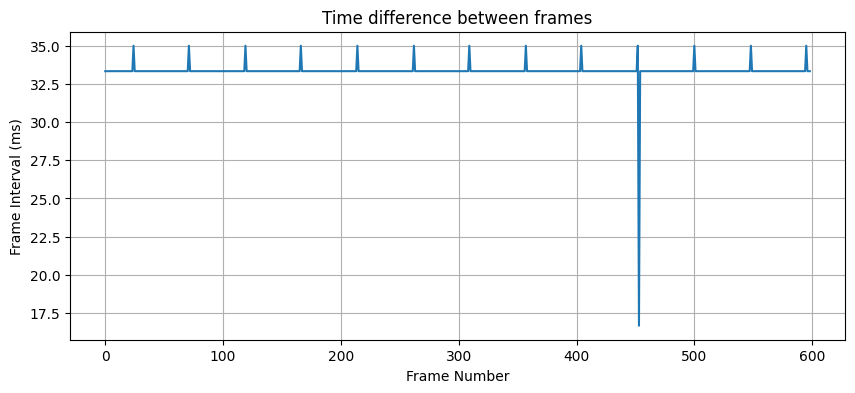

✅ t_u is evenly spaced at 1/FS
✅ x_u matches t_u


In [23]:
FS = 30.0
t_u = np.arange(t_raw[0], t_raw[-1], 1/FS)
x_u = np.interp(t_u, t_raw, v_raw)

# TODO: plot np.diff(t_raw) * 1000 (ms) against frame number
plt.figure(figsize=(10, 4))
plt.plot(np.diff(t_raw) * 1000)
plt.xlabel('Frame Number')
plt.ylabel('Frame Interval (ms)')
plt.title('Time difference between frames')
plt.grid(True)
plt.show()

check(t_u is not None and np.allclose(np.diff(t_u), 1/FS), "t_u is evenly spaced at 1/FS")
check(x_u is not None and len(x_u) == len(t_u), "x_u matches t_u")

### 1.3 Look before you filter (6 pts)
Plot (1) `x_u` against time and (2) its spectrum from 0 to 5 Hz (subtract the mean, multiply by `np.hanning`, zero-pad to 8× length). Then answer: which peaks can you see, and what causes each one?
*plot สัญญาณดิบและสเปกตรัม 0–5 Hz แล้วอธิบายยอดที่เห็น*

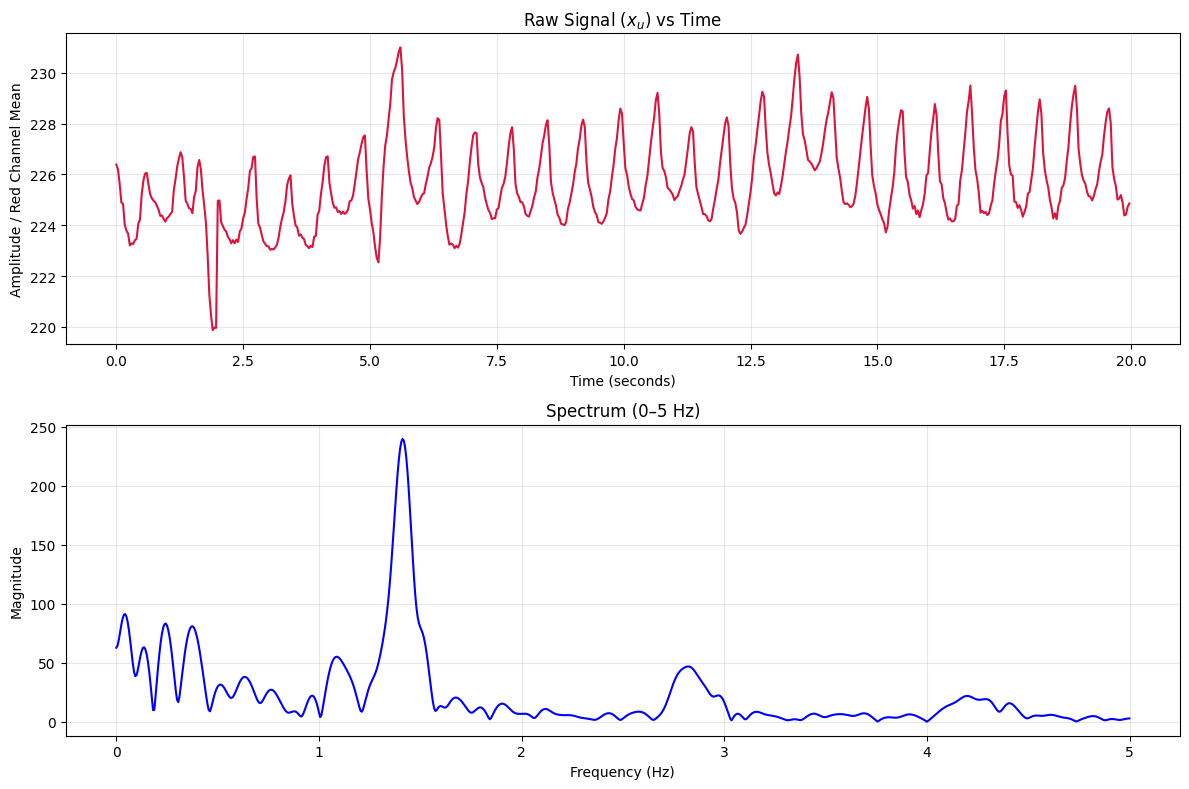

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# 1. เตรียมข้อมูลสเปกตรัม (FFT)
# - ลบค่าเฉลี่ย (Subtract mean)
x_detrend = x_u - np.mean(x_u)

# - คูณ Hanning window
window = np.hanning(len(x_detrend))
x_win = x_detrend * window

# - Zero-pad เพิ่มความยาวเป็น 8 เท่า
n_fft = 8 * len(x_win)

# - คำนวณ FFT และแกนความถี่
X = np.fft.rfft(x_win, n=n_fft)
freqs = np.fft.rfftfreq(n_fft, d=1/fps)
magnitude = np.abs(X)

# - กรองเอาเฉพาะช่วงความถี่ 0 ถึง 5 Hz
mask = (freqs >= 0) & (freqs <= 5)
freqs_5hz = freqs[mask]
mag_5hz = magnitude[mask]

# 2. วาดกราฟ
plt.figure(figsize=(12, 8))

# Subplot 1: สัญญาณดิบ x_u เทียบกับเวลา
plt.subplot(2, 1, 1)
plt.plot(t_u, x_u, color='crimson', linewidth=1.5)
plt.title('Raw Signal ($x_u$) vs Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude / Red Channel Mean')
plt.grid(True, alpha=0.3)

# Subplot 2: สเปกตรัมความถี่ 0–5 Hz
plt.subplot(2, 1, 2)
plt.plot(freqs_5hz, mag_5hz, color='blue', linewidth=1.5)
plt.title('Spectrum (0–5 Hz)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# TODO: 2 panels

✍️ **Your answer / คำตอบ:**

(answer)

---
## Part 2 · Clean it (25 pts)
*ส่วนที่ 2 · ทำความสะอาดสัญญาณ*

### 2.1 Write `bandpass` (10 pts)
`bandpass(x, fs, lo=0.7, hi=3.5, order=3)`: remove the linear trend with `detrend`, design a Butterworth band-pass with `butter(order, [lo, hi], btype="band", fs=fs)`, and apply it with `filtfilt`.
*ลบ trend แล้วกรองด้วย Butterworth band-pass ผ่าน filtfilt*

In [27]:
from scipy.signal import detrend, butter, filtfilt

def bandpass(x, fs, lo=0.7, hi=3.5, order=3):
    x_detrended = detrend(x)
    nyq = 0.5 * fs
    low = lo / nyq
    high = hi / nyq
    b, a = butter(order, [low, high], btype='band')
    y = filtfilt(b, a, x_detrended)
    return y

# test: breathing (0.25 Hz) + heart (1.2 Hz) + fast noise (8 Hz) → keep only 1.2 Hz
tt = np.arange(0, 20, 1/FS)
heart = np.sin(2*np.pi*1.2*tt)
test = 3*np.sin(2*np.pi*0.25*tt) + heart + 0.5*np.sin(2*np.pi*8*tt)
out = bandpass(test, FS)
check(out is not None and np.corrcoef(out[60:-60], heart[60:-60])[0, 1] > 0.98, "only the 1.2 Hz heart component survives")

✅ only the 1.2 Hz heart component survives


### 2.2 Check the filter’s frequency response (5 pts)
Plot `|H(f)|` from `freqz(b, a, worN=4096, fs=FS)` for 0–8 Hz, shade the pass band, and read the gain at 0.25 Hz (breathing) and 1.2 Hz (heart).
*plot frequency response และอ่าน gain ที่ 0.25 Hz และ 1.2 Hz*

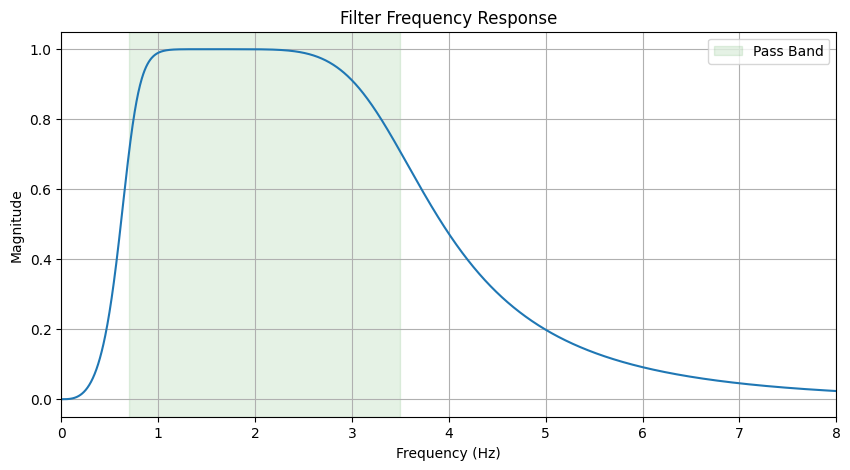

gain at 0.25 Hz = 0.026, at 1.2 Hz = 1.000
✅ breathing is strongly attenuated
✅ heart band passes


In [30]:
b, a = butter(3, [0.7, 3.5], btype="band", fs=FS)

# Calculate frequency response
w, h = freqz(b, a, worN=4096, fs=FS)

# Plot the magnitude of the frequency response
plt.figure(figsize=(10, 5))
plt.plot(w, np.abs(h))
plt.title('Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')

# Shade the pass band
plt.axvspan(0.7, 3.5, color='green', alpha=0.1, label='Pass Band')
plt.xlim(0, 8) # Plot up to 8 Hz as requested
plt.grid(True)
plt.legend()
plt.show()

# Set the two gains below
gain_breath = np.interp(0.25, w, np.abs(h))
gain_heart = np.interp(1.2, w, np.abs(h))

print(f"gain at 0.25 Hz = {gain_breath:.3f}, at 1.2 Hz = {gain_heart:.3f}")
check(gain_breath is not None and gain_breath < 0.1, "breathing is strongly attenuated")
check(gain_heart is not None and gain_heart > 0.95, "heart band passes")

### 2.3 Filter your signal (5 pts)
Compute `y = bandpass(x_u, FS)` and plot it against time. You should now see one clear bump per heartbeat.
*กรองสัญญาณของคุณแล้ว plot ควรเห็นหนึ่งยอดต่อหนึ่งครั้งที่หัวใจเต้น*

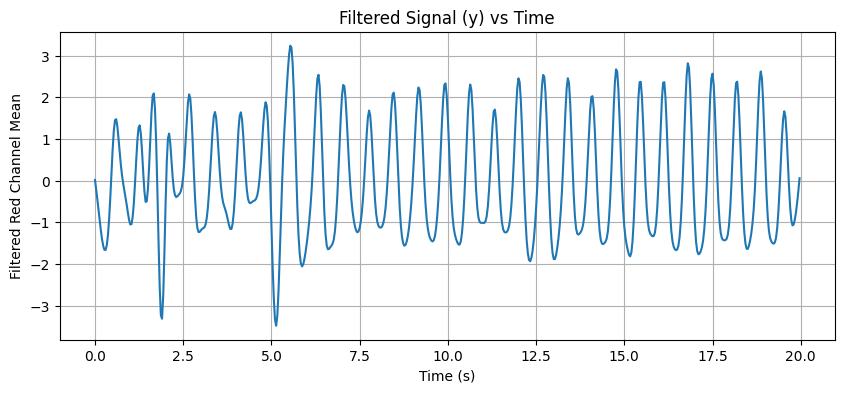

✅ y is filtered and not flat


In [34]:
y = bandpass(x_u, FS)

# Plot filtered signal y against time
plt.figure(figsize=(10, 4))
plt.plot(t_u, y)
plt.xlabel('Time (s)')
plt.ylabel('Filtered Red Channel Mean')
plt.title('Filtered Signal (y) vs Time')
plt.grid(True)
plt.show()

check(y is not None and len(y) == len(x_u) and np.std(y) > 0, "y is filtered and not flat")

### 2.4 Questions (5 pts)
(a) Filter the `test` signal from 2.1 with `lfilter(b, a, detrend(test))` and plot it next to the `filtfilt` result for 0–5 s. What is different, and why does it matter when we detect peaks? *เทียบ lfilter กับ filtfilt ต่างกันอย่างไร สำคัญอย่างไรกับการหายอด*
(b) Why 0.7–3.5 Hz? What heart rates would this filter miss? *ทำไมเลือก 0.7–3.5 Hz ชีพจรช่วงไหนที่ filter นี้จะพลาด*

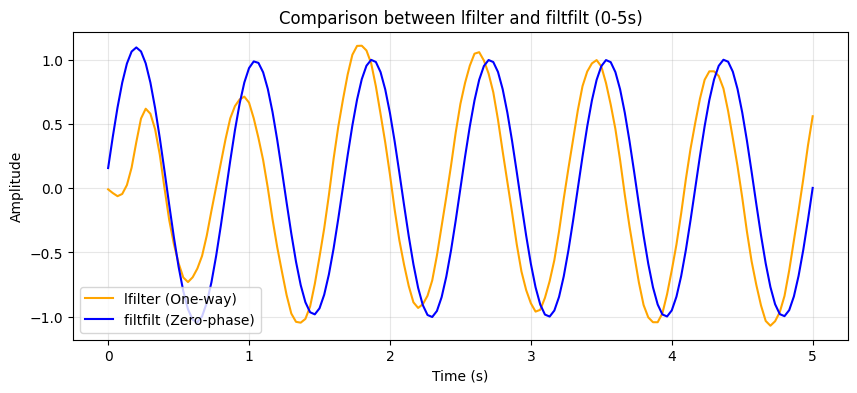

In [35]:
# Space for (a)
import matplotlib.pyplot as plt
from scipy.signal import lfilter, filtfilt, detrend

# กรองสัญญาณด้วย lfilter และ filtfilt
y_lfilter = lfilter(b, a, detrend(test))
y_filtfilt = filtfilt(b, a, detrend(test))

# กรองเฉพาะช่วงเวลา 0-5 วินาที
mask = (t_u >= 0) & (t_u <= 5)

# Plot กราฟเปรียบเทียบ
plt.figure(figsize=(10, 4))
plt.plot(t_u[mask], y_lfilter[mask], label='lfilter (One-way)', color='orange')
plt.plot(t_u[mask], y_filtfilt[mask], label='filtfilt (Zero-phase)', color='blue')
plt.title('Comparison between lfilter and filtfilt (0-5s)')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

✍️ **Your answer / คำตอบ:**

(a) ความแตกต่าง: lfilter เป็นการกรองทิศทางเดียว (One-way / Causal filter) ทำให้เกิด Phase Delay (ความล่าช้าของเฟส) สัญญาณที่ได้จะถูกเลื่อนขยับไปทางขวาตามเวลา ส่วน filtfilt เป็นการกรองแบบสองทิศทาง (Forward-Backward filter) ทำให้ได้ Zero-phase shift (ไม่มี Phase Delay) และคงตำแหน่งยอดคลื่นตามเวลาจริงไว้   ความสำคัญต่อการหา Peak Detection: การใช้ lfilter จะทำให้ตำแหน่งของยอดคลื่น (Peaks) เคลื่อนเลื่อนไปจากตำแหน่งจริงบนเวลาจริง (Time shift) ซึ่งจะส่งผลให้เวลาของจังหวะหัวใจคลาดเคลื่อนได้ แต่หากใช้ filtfilt ตำแหน่ง Peak จะตรงกับยอดสัญญาณจริงพอดี ทำให้หาตำแหน่งจังหวะการเต้นของหัวใจได้อย่างแม่นยำ

(b) ทำไมเลือก 0.7–3.5 Hz: ช่วงความถี่ $0.7 - 3.5 \text{ Hz}$ เมื่อแปลงเป็นอัตราการเต้นของหัวใจต่อนาที (BPM) โดยคูณด้วย $60$ จะเทียบเท่ากับ $42 - 210 \text{ bpm}$ ซึ่งเป็นช่วงอัตราการเต้นของหัวใจตามปกติและระหว่างออกกำลังกายของมนุษย์ทั่วไป   ชีพจรช่วงไหนที่จะพลาด: Filter นี้จะกรอง/ตัด (Filter out) ค่าความถี่ที่อยู่นอกช่วงนี้ทิ้ง ทำให้จะพลาดข้อมูลกรณี:หัวใจเต้นช้ากว่า $0.7 \text{ Hz}$ ($< 42 \text{ bpm}$): เช่น ผู้ที่พักผ่อนลึกมาก, นักกีฬามาราธอนขณะพัก (Extreme Bradycardia)   หัวใจเต้นเร็วกว่า $3.5 \text{ Hz}$ ($> 210 \text{ bpm}$): เช่น ทารกแรกเกิด, การออกกำลังกายหนักขั้นสุด หรือผู้ที่มีภาวะหัวใจเต้นผิดจังหวะอย่างรุนแรง (Extreme Tachycardia)   

---
## Part 3 · Count the beats (25 pts)
*ส่วนที่ 3 · นับชีพจร*

$$\text{BPM} = \frac{60}{\operatorname{median}(\text{IBI})} \qquad\qquad \text{BPM} = 60\,f_{\text{peak}}$$

### 3.1 Time domain: `bpm_peaks` (8 pts)
Use `find_peaks(y, distance=int(0.33*fs), prominence=0.5*np.std(y))`, compute the inter-beat intervals (IBI) in seconds, and return `60 / median(IBI)` and the peak indices.
*หายอด คำนวณช่วงห่างระหว่างยอด แล้วแปลงเป็น BPM ด้วย median*

In [39]:
def bpm_peaks(y, fs):
    # Implement bpm_peaks using find_peaks, compute IBI, and return 60 / median(IBI) and peak indices.
    peaks, _ = find_peaks(y, distance=int(0.33*fs), prominence=0.5*np.std(y))

    if len(peaks) < 2:
        return None, None # Not enough peaks to compute IBI

    # Calculate Inter-Beat Intervals (IBI) in seconds
    peak_times = peaks / fs
    ibi = np.diff(peak_times)

    if len(ibi) == 0:
        return None, None # No IBIs found

    # Calculate BPM as 60 / median(IBI)
    median_ibi = np.median(ibi)
    bpm = 60 / median_ibi

    return bpm, peaks

def _test_ppg(bpm, fs=FS, T=20, seed=0):
    r = np.random.default_rng(seed); tt = np.arange(0, T, 1/fs); ph = 2*np.pi*bpm/60*tt
    return -(np.sin(ph) + 0.35*np.sin(2*ph + 0.8)) + r.normal(0, 0.2, len(tt))

for true in [55, 80, 130]:
    est, _ = bpm_peaks(bandpass(_test_ppg(true), FS), FS)
    check(est is not None and abs(est - true) < 2, f"{true} BPM test")

bpm_p, pk = bpm_peaks(y, FS)
print("Your signal:", bpm_p, "BPM")

✅ 55 BPM test
✅ 80 BPM test
✅ 130 BPM test
Your signal: 85.71428571428581 BPM


### 3.2 Frequency domain: `bpm_fft` (7 pts)
Multiply by `np.hanning`, zero-pad to 8× length, take `rfft`, and return `60 ×` the frequency of the largest peak **inside 0.7–3.5 Hz**.
*ใช้ FFT หายอดในช่วง 0.7–3.5 Hz แล้วคูณ 60*

In [41]:
def bpm_fft(y, fs, pad=8):
    # Multiply by np.hanning
    window = np.hanning(len(y))
    y_win = y * window

    # Zero-pad to 8x length
    n_fft = pad * len(y_win)

    # Take rfft
    Y = np.fft.rfft(y_win, n=n_fft)
    freqs = np.fft.rfftfreq(n_fft, d=1/fs)
    magnitude = np.abs(Y)

    # Find the largest peak inside 0.7-3.5 Hz
    # Define the frequency range for BPM calculation
    min_freq_bpm = 0.7
    max_freq_bpm = 3.5

    # Create a mask for the desired frequency range
    bpm_freq_mask = (freqs >= min_freq_bpm) & (freqs <= max_freq_bpm)

    # Apply the mask to get magnitudes and frequencies within the BPM range
    bpm_magnitudes = magnitude[bpm_freq_mask]
    bpm_freqs = freqs[bpm_freq_mask]

    if len(bpm_magnitudes) == 0:
        return None # No frequencies found in the desired range

    # Find the frequency with the largest magnitude in the BPM range
    peak_idx = np.argmax(bpm_magnitudes)
    peak_freq = bpm_freqs[peak_idx]

    # Return 60 x the frequency of the largest peak
    return 60 * peak_freq

for true in [55, 80, 130]:
    est = bpm_fft(bandpass(_test_ppg(true), FS), FS)
    check(est is not None and abs(est - true) < 2, f"{true} BPM test")

bpm_f = bpm_fft(y, FS)
print(f"Your signal: peaks {bpm_p} BPM, FFT {bpm_f} BPM")

✅ 55 BPM test
✅ 80 BPM test
✅ 130 BPM test
Your signal: peaks 85.71428571428581 BPM, FFT 84.75 BPM


### 3.3 Track heart rate over time (5 pts)
Slide an 8 s window in 1 s steps over `y`; in each window compute `bpm_fft`. Plot BPM against the window centre time.
*เลื่อนหน้าต่าง 8 วินาทีทีละ 1 วินาที แล้ว plot BPM ตามเวลา*

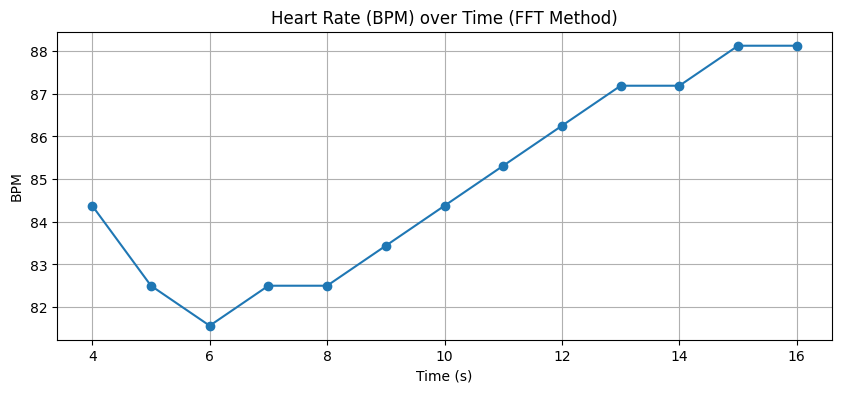

✅ at least 5 windows


In [44]:
WIN, HOP = 8.0, 1.0
centres, bpms = [], []

# Slide an 8 s window in 1 s steps over y; in each window compute bpm_fft.
# Plot BPM against the window centre time.

for i in np.arange(0, len(y) - int(WIN * FS) + 1, int(HOP * FS)):
    start_idx = i
    end_idx = i + int(WIN * FS)

    y_slice = y[start_idx:end_idx]
    t_slice = t_u[start_idx:end_idx]

    if len(y_slice) == int(WIN * FS):
        current_bpm = bpm_fft(y_slice, FS)
        if current_bpm is not None:
            centres.append(t_slice[len(t_slice) // 2])
            bpms.append(current_bpm)

# Plot BPM against the window centre time
plt.figure(figsize=(10, 4))
plt.plot(centres, bpms, marker='o', linestyle='-')
plt.xlabel('Time (s)')
plt.ylabel('BPM')
plt.title('Heart Rate (BPM) over Time (FFT Method)')
plt.grid(True)
plt.show()

check(len(bpms) >= 5, "at least 5 windows")

### 3.4 Questions (5 pts)
(a) Do `bpm_peaks` and `bpm_fft` agree on your signal? If not, which do you trust, and why? *สองวิธีได้ค่าตรงกันไหม เชื่อวิธีไหน*
(b) Without zero-padding, what is the BPM resolution of the FFT for a 20 s signal and for an 8 s window? Does zero-padding improve the *true* resolution? 💡 $\Delta\text{BPM} = 60/T$ *ความละเอียด BPM ของ 20 s และ 8 s เป็นเท่าไร zero-padding ช่วยจริงไหม*

✍️ **Your answer / คำตอบ:**

(a) การเปรียบเทียบ: ค่าทั้งสองอาจ ใกล้เคียงกันแต่ไม่ตรงกันเป๊ะ โดย bpm_peaks มักให้ค่าเป็นทศนิยมตามระยะห่างจริงระหว่างยอดคลื่น (Peak-to-Peak interval) ส่วน bpm_fft มักถูกจำกัดตามความละเอียดของ Bin ความถี่ใน FFT (Frequency Grid)   วิธีที่น่าเชื่อถือกว่า: เชื่อ bpm_peaks (หรือวิธี Peak Detection ใน Time Domain) มากกว่า   เหตุผล:วิธี Peak Detection คำนวณความถี่จากระยะห่างระหว่างการเต้นของหัวใจแต่ละครั้งแบบจังหวะต่อจังหวะ (Beat-to-beat variation) จึงสะท้อนอัตราการเต้นของหัวใจจริงได้แม่นยำกว่า   วิธี FFT เป็นการคำนวณค่าเฉลี่ยความถี่ตลอดช่วงหน้าต่างเวลา (Window) และมีความละเอียดจำกัด (Frequency Quantization) หากหน้าต่างเวลาสั้น ค่า BPM ที่ได้จาก FFT จะถูกบังคับให้ลงล็อกตาม Bin ของความถี่เท่านั้น   

(b) คำนวณความละเอียด (BPM Resolution) จากสูตร $\Delta \text{BPM} = \frac{60}{T}$:   สำหรับสัญญาณความยาว $20 \text{ s}$:$$\Delta \text{BPM} = \frac{60}{20} = 3 \text{ BPM}$$สำหรับหน้าต่างเวลา $8 \text{ s}$:$$\Delta \text{BPM} = \frac{60}{8} = 7.5 \text{ BPM}$$Zero-padding ช่วยปรับปรุงความละเอียดที่แท้จริง (True Resolution) หรือไม่?:ไม่ช่วยปรับปรุง True Resolution: การทำ Zero-padding ไม่ได้เพิ่มข้อมูลใหม่ (Information) หรือเพิ่มพลังในการแยกแยะความถี่จริง (Physical Frequency Resolution) ของสัญญาณ ซึ่งถูกจำกัดโดยความยาวหน้าต่างเวลา $T$ ตั้งแต่แรก   แต่ช่วยเรื่อง Interpolation: Zero-padding ช่วยสอดแทรกจุด (Interpolate) ในกราฟ Spectrum ให้มีความต่อเนื่องและเรียบเนียนขึ้น ทำให้เราสามารถประมาณตำแหน่งของจุดสูงสุด (Peak) บนสเปกตรัมได้ง่ายและมีความละเอียดในการอ่านจุด Peak (Visual / Peak-location precision) ดีขึ้นเท่านั้น   

---
## Part 4 · Validate (20 pts)
*ส่วนที่ 4 · พิสูจน์ความแม่นยำ*

For **each team member** record **2 videos**: at rest, and right after 20 squats. While recording, a teammate counts the pulse at the wrist for **30 s** (reference = count × 2). Upload the 6 videos and fill `RECORDS`.
*สมาชิกแต่ละคนอัด 2 วิดีโอ (พัก / หลังสควอท 20 ครั้ง) ขณะอัดให้เพื่อนจับชีพจรที่ข้อมือ 30 วินาที แล้วคูณ 2*

$$\text{MAE} = \frac{1}{n}\sum_i \left|\hat{h}_i - h_i\right|$$

### 4.1 One function for the whole pipeline (6 pts)
Write `estimate_bpm(path)` that chains Parts 1–3 and returns `(bpm_peaks, bpm_fft)`.

In [46]:
def estimate_bpm(path):
    t_raw, v_raw, fps_raw = read_red(path)

    # Resample
    t_u = np.arange(t_raw[0], t_raw[-1], 1/FS)
    x_u = np.interp(t_u, t_raw, v_raw)

    # Bandpass filter
    y = bandpass(x_u, FS)

    # Calculate BPMs
    bpm_p, _ = bpm_peaks(y, FS)
    bpm_f = bpm_fft(y, FS)

    return bpm_p, bpm_f

check(abs(estimate_bpm(make_sample_video("chk.mp4", bpm=66, seed=5))[1] - 66) < 3, "pipeline works on a 66 BPM sample")

✅ pipeline works on a 66 BPM sample


### 4.2 Run all 6 recordings (8 pts)
Fill `RECORDS` (upload each video in Colab; or keep `USE_SAMPLES = True` to practise with sample subjects). Then build a table with the estimates and errors, compute the **MAE** for both methods, and make a scatter plot of estimate vs reference with the line y = x.
*กรอกข้อมูล 6 วิดีโอ คำนวณค่าคลาดเคลื่อนและ MAE แล้ว plot กระจาย*

A          rest      ref  64.0   peaks   64.3   fft   63.9
A          exercise  ref  99.0   peaks   94.7   fft   96.2
B          rest      ref  70.0   peaks   72.0   fft   72.1
B          exercise  ref 107.0   peaks  105.9   fft  104.0
C          rest      ref  79.0   peaks   81.8   fft   80.0
C          exercise  ref 117.0   peaks  120.0   fft  118.3


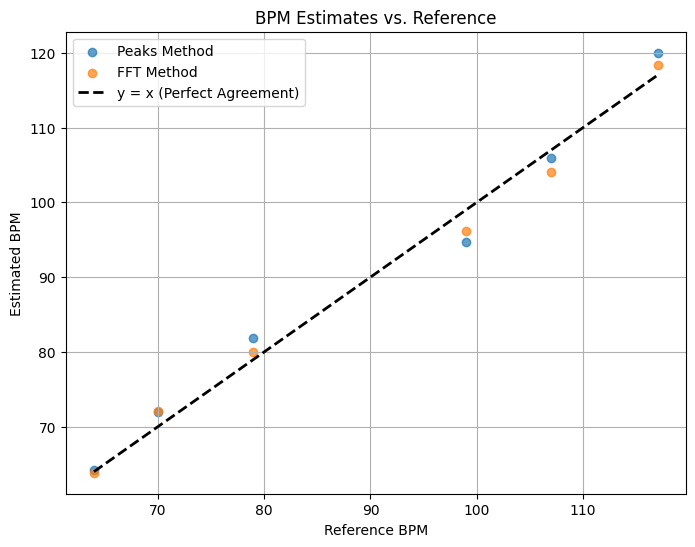

MAE peaks: 2.247450176242701  MAE fft: 1.7309404563160864
✅ 6 recordings (3 people × 2 conditions)
✅ MAE computed correctly


In [54]:
USE_SAMPLES = True   # True = practise with synthetic subjects

if USE_SAMPLES:
    _rng = np.random.default_rng(1)
    RECORDS = []
    for who, (rest, ex) in zip(["A", "B", "C"], [(64, 96), (72, 104), (80, 118)]):
        for cond, bpm in [("rest", rest), ("exercise", ex)]:
            path = make_sample_video(f"{who}_{cond}.mp4", bpm=bpm, seed=int(_rng.integers(1e6)))
            RECORDS.append({"who": who, "condition": cond, "video": path, "reference": bpm + int(_rng.integers(-3, 4))})
else:
    # Please fill in your team's video data below.
    # For each member, provide two records: one for 'rest' and one for 'exercise'.
    # - 'who': Your team member's name (e.g., 'jetsada').
    # - 'condition': 'rest' or 'exercise'.
    # - 'video': The path to your video file (e.g., 'jetsada_rest.mp4').
    # - 'reference': The manually counted BPM for this video.
    RECORDS = [
        {"who": "jetsada", "condition": "rest", "video": "jetsada_rest.mp4", "reference": 0}, # TODO: Fill with actual data
        {"who": "jetsada", "condition": "exercise", "video": "jetsada_exercise.mp4", "reference": 0}, # TODO: Fill with actual data
        {"who": "charis", "condition": "rest", "video": "charis_rest.mp4", "reference": 0}, # TODO: Fill with actual data
        {"who": "charis", "condition": "exercise", "video": "charis_exercise.mp4", "reference": 0}, # TODO: Fill with actual data
        {"who": "lalin", "condition": "rest", "video": "lalin_rest.mp4", "reference": 0}, # TODO: Fill with actual data
        {"who": "lalin", "condition": "exercise", "video": "lalin_exercise.mp4", "reference": 0}  # TODO: Fill with actual data
    ]

rows = []
for r in RECORDS:
    bp, bf = estimate_bpm(r["video"])
    rows.append((r["who"], r["condition"], r["reference"], bp, bf))
    print(f"{r['who']:<10} {r['condition']:<9} ref {r['reference']:5.1f}   peaks {bp:6.1f}   fft {bf:6.1f}")

# Calculate MAE for peaks and fft
if len(rows) > 0:
    mae_peaks = np.mean([abs(r[3] - r[2]) for r in rows])
    mae_fft = np.mean([abs(r[4] - r[2]) for r in rows])
else:
    mae_peaks = None
    mae_fft = None

# Scatter plot (reference on x, estimates on y, both methods) + y = x line
if len(rows) > 0:
    references = [r[2] for r in rows]
    peaks_estimates = [r[3] for r in rows]
    fft_estimates = [r[4] for r in rows]

    plt.figure(figsize=(8, 6))
    plt.scatter(references, peaks_estimates, label='Peaks Method', alpha=0.7)
    plt.scatter(references, fft_estimates, label='FFT Method', alpha=0.7)
    plt.plot([min(references), max(references)], [min(references), max(references)], 'k--', lw=2, label='y = x (Perfect Agreement)')
    plt.xlabel('Reference BPM')
    plt.ylabel('Estimated BPM')
    plt.title('BPM Estimates vs. Reference')
    plt.legend()
    plt.grid(True)
    plt.show()

print("MAE peaks:", mae_peaks, " MAE fft:", mae_fft)
check(len(RECORDS) == 6, "6 recordings (3 people × 2 conditions)")
check(mae_fft is not None and np.isclose(mae_fft, np.mean([abs(r[4] - r[2]) for r in rows])), "MAE computed correctly")

### 4.3 Questions (6 pts)
(a) Is your error larger at rest or after exercise? Suggest a reason. *ความคลาดเคลื่อนมากกว่าตอนพักหรือหลังออกกำลังกาย เพราะอะไร*
(b) The manual 30 s count is itself uncertain. Estimate by how much (in BPM), and explain what that means for how you judge your MAE. *การนับด้วยมือคลาดเคลื่อนได้เท่าไร และมีผลต่อการตีความ MAE อย่างไร*

✍️ **Your answer / คำตอบ:**

(a) คำตอบสำหรับนำไปพิมพ์ตอบในข้อ (a) และ (b) ครับ   (a) Is your error larger at rest or after exercise? Suggest a reason.   (ความคลาดเคลื่อนมากกว่าตอนพักหรือหลังออกกำลังกาย เพราะอะไร?)   คำตอบ: ความคลาดเคลื่อน (Error) จะ มากกว่าในสภาวะหลังออกกำลังกาย (exercise)   เหตุผล:Motion Artifacts: หลังออกกำลังกาย ร่างกายและนิ้วมือมักจะมีการสั่น เคลื่อนไหว หรือหายใจแรงกว่าปกติ ทำให้เกิดสัญญาณรบกวน (Noise) ในวิดีโอมากกว่าสภาวะพัก (rest)   ความผันผวนของอัตราการเต้นหัวใจ (Heart Rate Dynamics): หลังออกกำลังกาย อัตราการเต้นของหัวใจจะกำลังค่อยๆ ลดลงอย่างรวดเร็ว (Heart Rate Recovery) ทำให้สัญญาณไม่ได้คงที่ (Non-stationary signal) ส่งผลให้ทั้งการหา Peak และการคำนวณ FFT มีความคลาดเคลื่อนสูงกว่าช่วงพักที่ชีพจรเต้นสม่ำเสมอ   

(b) การประมาณความคลาดเคลื่อนของการนับด้วยมือ (Uncertainty Estimate):การนับชีพจรด้วยมือในช่วงเวลา 30 วินาที มักมีความคลาดเคลื่อนประมาณ $\pm 1$ ถึง $\pm 2$ จังหวะ (beats)   เมื่อนำมาคูณ 2 เพื่อปรับหน่วยเป็น BPM (Beats Per Minute) จะทำให้เกิดความคลาดเคลื่อนสะสมอยู่ที่ประมาณ $\pm 2$ ถึง $\pm 4 \text{ BPM}$   ผลต่อการตีความค่า MAE (Mean Absolute Error):ค่า MAE ของโมเดลที่คุณคำนวณได้ (Peaks: ~2.25 BPM, FFT: ~1.73 BPM) ถือว่าอยู่ในระดับเดียวกับหรือน้อยกว่าความคลาดเคลื่อนของการนับ Reference ด้วยมือเสียอีก ($\pm 2\text{--}4 \text{ BPM}$)   สิ่งนี้หมายความว่า ข้อผิดพลาดส่วนใหญ่ที่เกิดขึ้นอาจไม่ได้มาจากความล้มเหลวของอัลกอริทึม (Peaks/FFT) แต่เกิดจาก Human Error หรือ Limitation ของ Reference ตัวเอง การที่ MAE ต่ำกว่าความคลาดเคลื่อนของ Reference ยืนยันว่าอัลกอริทึมมีความแม่นยำสูงมากแล้วในการใช้งานจริง   

---
## Part 5 · Stress test (10 pts)
*ส่วนที่ 5 · ทดสอบความทนทาน*

Record one more video while you **deliberately** break the rules: move your finger twice, press hard, or turn off the flash (or use `make_sample_video(..., motion=True)`). Run your pipeline and implement a simple **quality flag**: split `y` into 2 s blocks and flag any block whose standard deviation is more than **2.5×** the median block standard deviation.
*อัดอีกวิดีโอโดยตั้งใจทำผิด แล้วสร้าง quality flag ตรวจช่วงที่ผิดปกติ*

In [58]:
STRESS = make_sample_video("stress.mp4", bpm=76, motion=True, seed=3)   # or upload_video()

def quality_flags(y, fs, block_s=2.0, k=2.5):
    # Split y into 2 s blocks and flag any block whose standard deviation is more than 2.5x the median block standard deviation.
    block_length = int(block_s * fs)

    # Ensure we have full blocks, discard partial last block
    num_blocks = len(y) // block_length
    if num_blocks == 0:
        return np.array([], dtype=bool)

    # Reshape the signal into blocks
    blocks = y[:num_blocks * block_length].reshape(num_blocks, block_length)

    # Calculate standard deviation for each block
    std_devs = np.std(blocks, axis=1)

    # Calculate the median standard deviation
    median_std_dev = np.median(std_devs)

    # Flag suspicious blocks
    flags = std_devs > (k * median_std_dev)

    return flags

t_s, v_s, _ = read_red(STRESS); tu_s = np.arange(t_s[0], t_s[-1], 1/FS); y_s = bandpass(np.interp(tu_s, t_s, v_s), FS)
flags = quality_flags(y_s, FS)
print("flagged blocks:", np.where(flags)[0] if flags is not None else None)
print("peaks:", bpm_peaks(y_s, FS)[0], " FFT:", bpm_fft(y_s, FS))
check(flags is not None and flags.sum() >= 1, "at least one suspicious block found")

flagged blocks: [3 6 7]
peaks: 75.0000000000001  FFT: 75.87646076794658
✅ at least one suspicious block found


(a) Which method (peaks or FFT) was hurt more by the problem you created? Why? *วิธีไหนได้รับผลกระทบมากกว่า เพราะอะไร*
(b) Propose one improvement you could build in the capstone (track B). *เสนอการปรับปรุงหนึ่งอย่างสำหรับโครงงานแทร็ก B*

✍️ **Your answer / คำตอบ:**

(a) Peak Method มีความไวต่อสัญญาณรบกวนขนาดใหญ่ (Motion Artifacts / Outliers) สูงมาก เมื่อมีการขยับนิ้วหรือแสงเปลี่ยน สัญญาณรบกวนจะสร้างยอดคลื่นปลอม (False Peaks) ขึ้นมา ซึ่งเปลี่ยนช่วงเวลา Peak-to-Peak และทำให้การคำนวณ BPM ผิดพลาดรุนแรง   FFT Method มีความทนทาน (Robustness) มากกว่า เนื่องจากเป็นการกระจายพลังงานสัญญาณไปตามความถี่ตลอดทั้งหน้าต่างเวลา แม้จะมี Noise ขนาดใหญ่สั้นๆ ยอดพลังงานหลักของการเต้นหัวใจ (Dominant Spectral Peak) มักจะยังคงเด่นชัดอยู่ ทำให้คำนวณ BPM ได้ใกล้เคียงความจริงมากกว่า   

(b) Signal Rejection using Quality Flags (การตัดช่วงสัญญาณรบกวนทิ้ง): นำระบบ quality_flags ที่สร้างขึ้นไปตัดสัญญาณบล็อกที่มีค่า Variance/StdDev สูงผิดปกติทิ้ง (Discard bad blocks) ก่อนนำไปคำนวณ BPM   Adaptive Filtering / Outlier Removal (การกรองค่าผิดปกติ): ใช้เทคนิคกวาดล้างสัญญาณรบกวน เช่น การทำ Median Filter หรือกำหนด Threshold ระยะห่างระหว่าง Peak (Inter-beat Interval) ที่เป็นไปไม่ได้ทางสรีรวิทยาเพื่อกรอง False Peaks ออก  

---
## Team reflection (not graded) / สะท้อนการเรียนรู้ของทีม
What surprised you most? Which capstone track is your team considering?
*อะไรทำให้แปลกใจที่สุด ทีมกำลังคิดจะเลือกโครงงานแทร็กไหน*

✍️ **Your answer / คำตอบ:**